# LedgerFlow — Feature Analysis

Analyses the 35-feature matrix (`data/processed/features.parquet`) and the evaluation artifacts in `reports/`. Run `dvc repro` first.

In [1]:
import json
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "params.yaml").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
print("project root:", ROOT)


project root: /Users/chetan/LedgerFlow


In [2]:
feat = pd.read_parquet(ROOT / 'data/processed/features.parquet')
feature_cols = [c for c in feat.columns if c.startswith('purchase_')]
print('matrix:', feat.shape, '| features:', len(feature_cols))
feat[feature_cols].describe().T.head(8)

matrix: (2000, 37) | features: 35


,count,mean,std,min,25%,50%,75%,max
purchase_count_1h,2000.0,0.008500,0.091826,0.0,0.0,0.0,0.0,1.00
purchase_amount_sum_1h,2000.0,0.206005,3.785361,0.0,0.0,0.0,0.0,140.04
purchase_amount_mean_1h,2000.0,0.206005,3.785361,0.0,0.0,0.0,0.0,140.04
purchase_amount_std_1h,2000.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.00
purchase_amount_min_1h,2000.0,0.206005,3.785361,0.0,0.0,0.0,0.0,140.04
purchase_amount_max_1h,2000.0,0.206005,3.785361,0.0,0.0,0.0,0.0,140.04
purchase_amount_last_1h,2000.0,0.206005,3.785361,0.0,0.0,0.0,0.0,140.04
purchase_count_6h,2000.0,0.040000,0.201048,0.0,0.0,0.0,0.0,2.00


## Feature importance (mean across models, SHAP for trees)

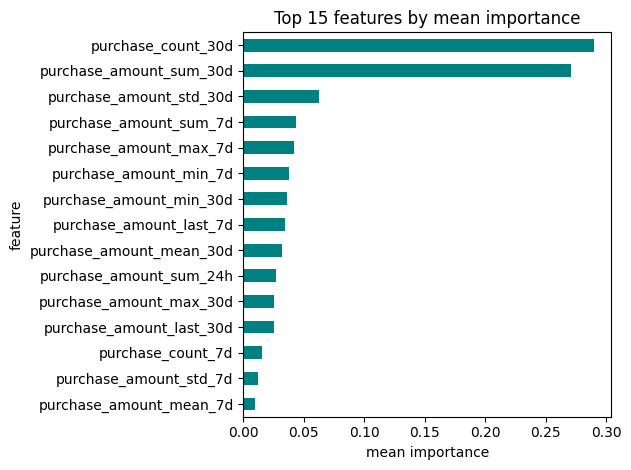

,feature,mean_importance
0,purchase_count_30d,0.289487
1,purchase_amount_sum_30d,0.270663
2,purchase_amount_std_30d,0.062828
3,purchase_amount_sum_7d,0.043879
4,purchase_amount_max_7d,0.042078
5,purchase_amount_min_7d,0.037681
6,purchase_amount_min_30d,0.036062
7,purchase_amount_last_7d,0.034688
8,purchase_amount_mean_30d,0.031925
9,purchase_amount_sum_24h,0.026978


In [3]:
imp = pd.read_json(ROOT / 'reports/feature_importance.json')
top = imp.sort_values('mean_importance', ascending=False).head(15)
ax = top.set_index('feature')['mean_importance'][::-1].plot.barh(
    title='Top 15 features by mean importance', color='teal')
ax.set_xlabel('mean importance'); plt.tight_layout(); plt.show()
top[['feature','mean_importance']].reset_index(drop=True)

## Model comparison

recommended: LightGBM


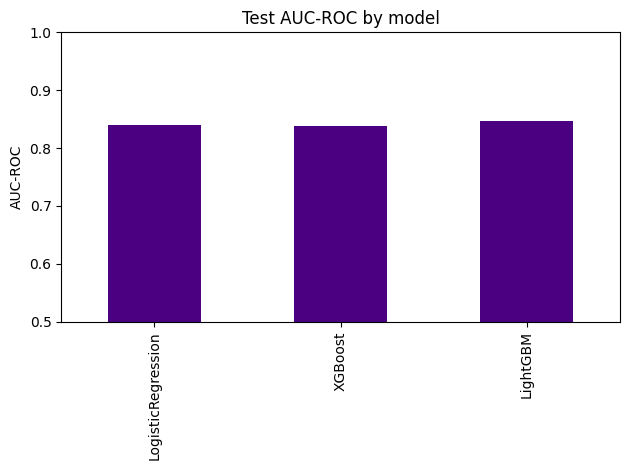

,auc_roc,avg_precision,brier_score,log_loss,f1
LogisticRegression,0.8403,0.8218,0.1716,0.5663,0.7714
XGBoost,0.8373,0.8339,0.1659,0.5046,0.7397
LightGBM,0.8467,0.8478,0.1616,0.4926,0.7554


In [4]:
ev = json.loads((ROOT / 'reports/eval_metrics.json').read_text())
md = pd.DataFrame(ev['models']).T[['auc_roc','avg_precision','brier_score','log_loss','f1']]
print('recommended:', ev['recommended'])
ax = md['auc_roc'].plot.bar(title='Test AUC-ROC by model', color='indigo')
ax.set_ylim(0.5, 1.0); ax.set_ylabel('AUC-ROC'); plt.tight_layout(); plt.show()
md.round(4)

## Correlation of top features with the label

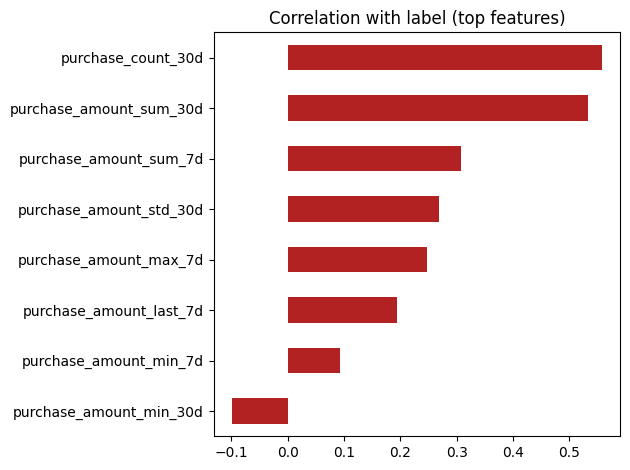

purchase_amount_min_30d   -0.098
purchase_amount_min_7d     0.092
purchase_amount_last_7d    0.194
purchase_amount_max_7d     0.247
purchase_amount_std_30d    0.268
purchase_amount_sum_7d     0.308
purchase_amount_sum_30d    0.533
purchase_count_30d         0.557
Name: label, dtype: float64

In [5]:
cols = top['feature'].head(8).tolist()
corr = feat[cols + ['label']].corr()['label'].drop('label').sort_values()
ax = corr.plot.barh(title='Correlation with label (top features)', color='firebrick')
plt.tight_layout(); plt.show()
corr.round(3)

## Low-signal features (removal candidates)

In [6]:
ls = json.loads((ROOT / 'reports/low_signal_features.json').read_text())
print('threshold:', ls['threshold'], '| flagged:', len(ls['features']))
ls['features']

threshold: 0.001 | flagged: 14


['purchase_amount_sum_1h',
 'purchase_amount_last_6h',
 'purchase_amount_max_6h',
 'purchase_amount_min_6h',
 'purchase_amount_std_6h',
 'purchase_amount_mean_6h',
 'purchase_amount_sum_6h',
 'purchase_count_6h',
 'purchase_amount_last_1h',
 'purchase_amount_max_1h',
 'purchase_amount_min_1h',
 'purchase_amount_std_1h',
 'purchase_amount_mean_1h',
 'purchase_count_1h']